# Tarea Semanal 1

> En este primer trabajo comenzaremos por diseñar un generador de señales que utilizaremos en las primeras simulaciones que hagamos. La primer tarea consistirá en programar una función que genere señales senoidales y que permita parametrizar:
>
> - la amplitud máxima de la senoidal (volts)
> - su valor medio (volts)
> - la frecuencia (Hz)
> - la fase (radianes)
> - la cantidad de muestras digitalizada por el ADC (# muestras)
> - la frecuencia de muestreo del ADC.
>
> Es decir que la función que uds armen debería admitir se llamada de la siguiente manera <br>
>```tt, xx = mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs)```

## Inicio del codigp 

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

### Primitivas generales

Inicialmente defino funciones de uso general para mantener el codigo mas adelante limpio

In [2]:

def undB (dB):
    return 10**(dB/10)

def dB (x):
    return 10*np.log10(x)

### Definicion de parametros

En este bloque se definen los parametros de sampleo y los parametros aplicados por defecto en el generador de señales

In [3]:

#Params Generales 
fs = 1000       #500Hz de BW
ts = 1/fs
N = fs          #DeltaF = 1Hz; norm
df = fs/N
dt = 1/df

#Params func 
vmax = 1.        
dc = 0.          
ff = 5
ph = 0.
snr = 30

## Inicio del codigo del generador de funciones

Las funciones basicas van a ser llamadas desde un wrapper implementado mas abajo

### Sin()

Se implementa mediante numpy

In [4]:

def miSin (vmax, dc, ff, ph, nn, fs):
    tt = np.arange(nn) * 1/fs
    xx = dc + vmax * np.sin( 2 * np.pi * ff * tt + ph)
    pa = vmax**2/2
    return (tt, xx, pa)


### PWM

Se implementa una PWM, la cual sera reutilizada por el wrapper para generar cuadradas
Se convierte el tiempo efectivo a tiempo normalizado dentro de un ciclo para mayor facilidad de generar las funciones

$$
p_i = \frac{\left(t_i + T_0 \frac{\Theta_0}{2\pi} \right) \% T_0}{T_0} 
= \left(t_i f_0 + \frac{\Theta_0}{2\pi} \right) \% 1
$$


In [5]:
def miPWM (vmax, dc, ff, ph, nn, fs, duty):
    tt = np.arange(nn) * 1/fs
    xx = np.arange(nn)
    pp = (tt*ff + ph/(2*np.pi)) % 1 #time as proportion of cycle

    for i in range(len(pp)):
        if(pp[i] < duty):
            xx[i] = vmax
        else:
            xx[i] = 0
    xx = xx + dc - (vmax * duty)
    pa = vmax**2*duty
    return (tt, xx, pa)


### Triangular desbalanceada

Se implementa una triangular donde el periodo creciente y el decreciente son iguales. 
Se implementa ya que la misma se puede reutilizar para triangulares y dientes de sierra

In [6]:
def miScalene (vmax, dc, ff, ph, nn, fs, duty):
    tt = np.arange(nn) * 1/fs
    xx = np.arange(nn + 0.0)
    pp = (tt*ff + ph/(2*np.pi)) % 1 #time as proportion of cycle

    for i in range(len(pp)):
        if(pp[i] < duty):
            xx[i] = (vmax/duty) * pp[i] 
        else:
            xx[i] = (vmax/(1-duty)) * (1-pp[i])
    xx = xx + dc - (vmax/2)
    pa = vmax**2/3
    return (tt, xx, pa)


### Ruido aleatorio

Se implementa una funcion de ruido dada por Potencia, para poder luegego agregarle ruido a nuestras funciones

In [7]:
def miNoise (Pot, nn):
    xna = np.random.normal(loc = 0, scale = np.sqrt(Pot), size = nn) 
    return xna

### Wrapper
Finalmente se implementa el wrapper, que permite generar multiples funciones en base a las primitivas definidas. Toma adicionalmente un valor de snr para agregar ruido (-1 = desactivado)

In [8]:
def miSignalGenerator (sigType = "sine", vmax = vmax, dc = dc, ff = ff, ph = ph, nn = N, fs = fs, snr = -1, duty = 0.5):
    if ((duty > 1) or (duty < 0)):
      print("dutycyle invalido")
      return
    
    if ((snr < 0) and (snr != -1)):
      print("snr invalido")
      return

    match sigType:
        case "sine":
            tt, xx, pa = miSin(vmax = vmax, dc = dc, ff = ff, ph = ph, nn = nn, fs = fs)

        case "saw":
            tt, xx, pa = miScalene(vmax = vmax, dc = dc, ff = ff, ph = ph, nn = nn, fs = fs, duty = 1)
        case "revSaw":
            tt, xx, pa = miScalene(vmax = vmax, dc = dc, ff = ff, ph = ph, nn = nn, fs = fs, duty = 0)
        case "tri":
            tt, xx, pa = miScalene(vmax = vmax, dc = dc, ff = ff, ph = ph, nn = nn, fs = fs, duty = 0.5)
        case "asTri":
            tt, xx, pa = miScalene(vmax = vmax, dc = dc, ff = ff, ph = ph, nn = nn, fs = fs, duty = duty)

        case "square":
            tt, xx, pa = miPWM(vmax = vmax, dc = dc, ff = ff, ph = ph, nn = nn, fs = fs, duty = 0.5)
        case "PWM":
            tt, xx, pa = miPWM(vmax = vmax, dc = dc, ff = ff, ph = ph, nn = nn, fs = fs, duty = duty)

        case _:
            print("sigType invlaido")
            tt = np.arange(N)
            xx = np.arange(N)
    
    if (snr != -1):
        Pna = pa / undB(snr)
        xx = xx + miNoise(Pot = Pna, nn = nn)
    return (tt, xx)

## Funciones de onda producida

In [9]:
def testSigGen(sigType, vmax = vmax, dc = dc, ff = ff, ph = ph, fs = fs, snr = -1, duty = 0.5):
  tt, xx = miSignalGenerator(sigType = sigType, vmax = vmax, dc = dc, ff = ff, ph = ph, nn = N, fs = fs, snr = snr, duty = duty)
  plt.figure(1, figsize = (12,4))
  plt.clf()

  plt.plot(tt,xx, linewidth=1.5)
  plt.xlabel('Tiempo (s)')
  plt.ylabel('Amplitud (V)')
  plt.grid(linestyle='-', alpha=0.5)
  plt.title(f'{sigType} de {ff}Hz, {vmax}V, con offset de {dc}V, {ph}r de fase y {snr}snr')
  plt.tight_layout()
  plt.show()
  return

### Senoidal

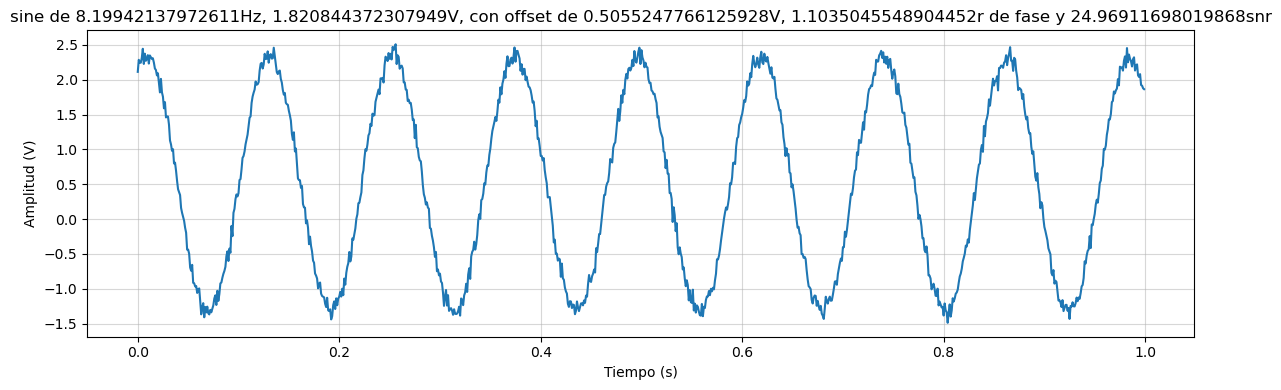

In [10]:
testSigGen (
sigType = "sine",
vmax = np.random.uniform(0.5, 2),
dc = np.random.uniform(0.5, 2),
ff = np.random.uniform(6, 12),
ph = np.random.uniform(0, 2*np.pi),
fs = fs,
snr = np.random.uniform(10, 100)
)

### Diente de sierra

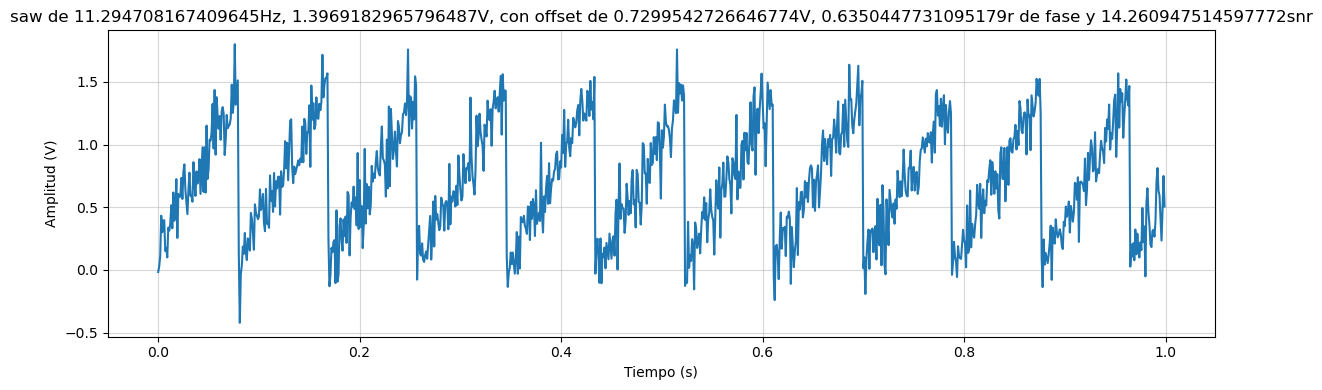

In [11]:
testSigGen (
sigType = "saw",
vmax = np.random.uniform(0.5, 2),
dc = np.random.uniform(0.5, 2),
ff = np.random.uniform(6, 12),
ph = np.random.uniform(0, 2*np.pi),
fs = fs,
snr = np.random.uniform(10, 100)
)

### Diente de sierra invertido

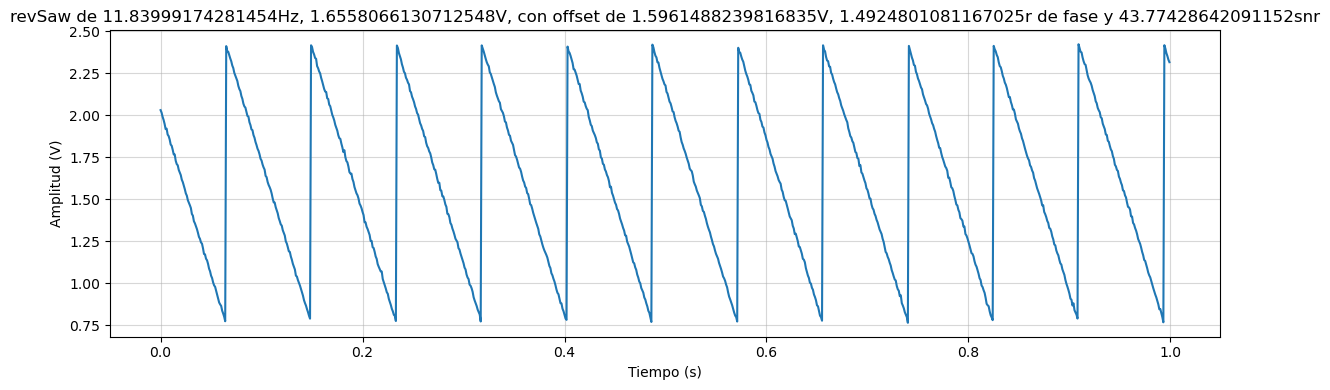

In [12]:
testSigGen (
sigType = "revSaw",
vmax = np.random.uniform(0.5, 2),
dc = np.random.uniform(0.5, 2),
ff = np.random.uniform(6, 12),
ph = np.random.uniform(0, 2*np.pi),
fs = fs,
snr = np.random.uniform(10, 100)
)

### Triangular

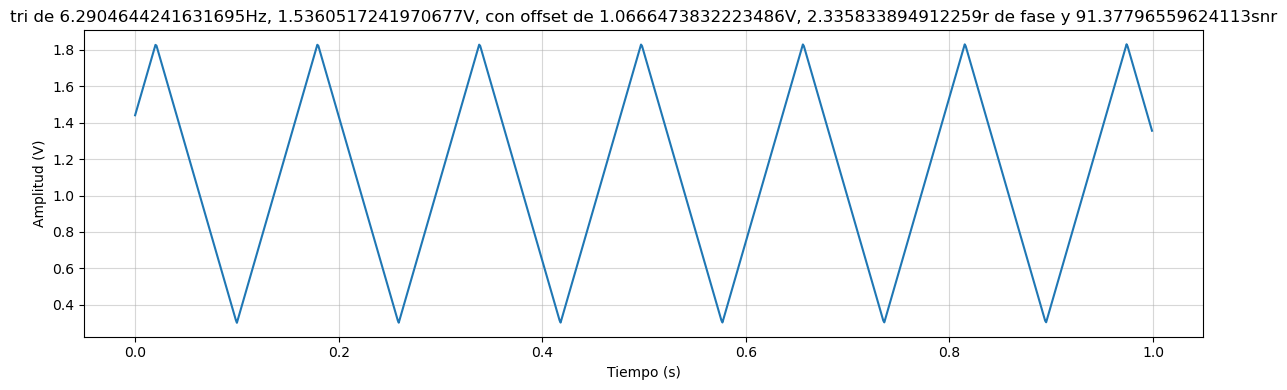

In [13]:
testSigGen (
sigType = "tri",
vmax = np.random.uniform(0.5, 2),
dc = np.random.uniform(0.5, 2),
ff = np.random.uniform(6, 12),
ph = np.random.uniform(0, 2*np.pi),
fs = fs,
snr = np.random.uniform(10, 100)
)

### Triengular asimetrica

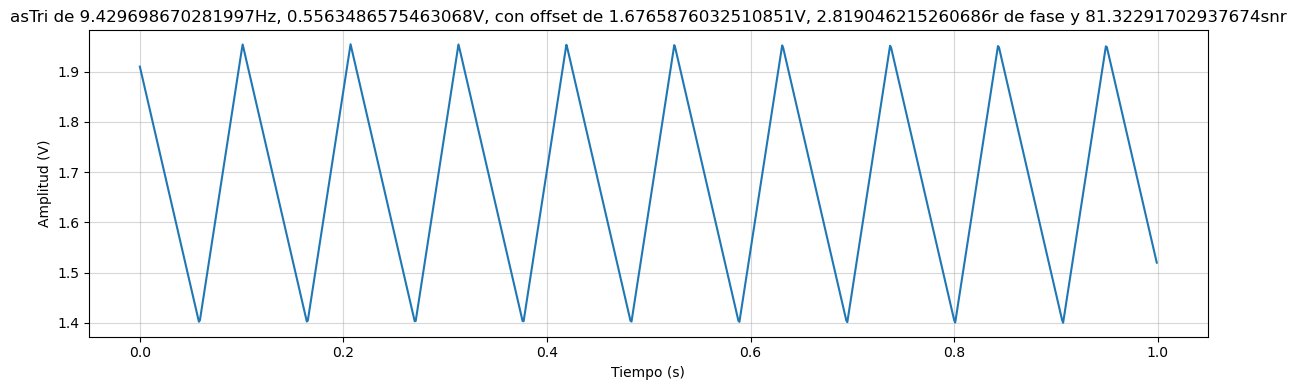

In [14]:
testSigGen (
sigType = "asTri",
vmax = np.random.uniform(0.5, 2),
dc = np.random.uniform(0.5, 2),
ff = np.random.uniform(6, 12),
ph = np.random.uniform(0, 2*np.pi),
fs = fs,
snr = np.random.uniform(10, 100),
duty = np.random.uniform(0.1, 0.9)
)

### PWM

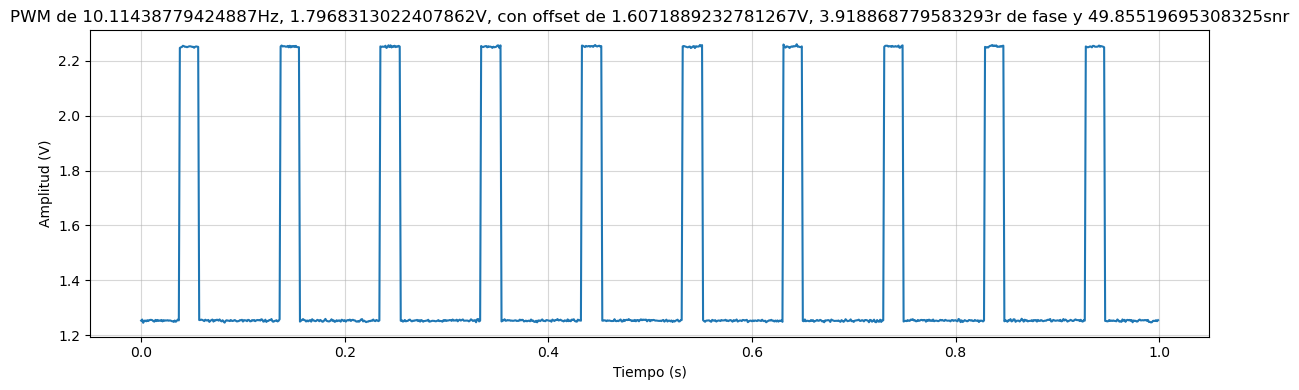

In [15]:
testSigGen (
sigType = "PWM",
vmax = np.random.uniform(0.5, 2),
dc = np.random.uniform(0.5, 2),
ff = np.random.uniform(6, 12),
ph = np.random.uniform(0, 2*np.pi),
fs = fs,
snr = np.random.uniform(10, 100),
duty = np.random.uniform(0.1, 0.9)
)

### Cuadrada

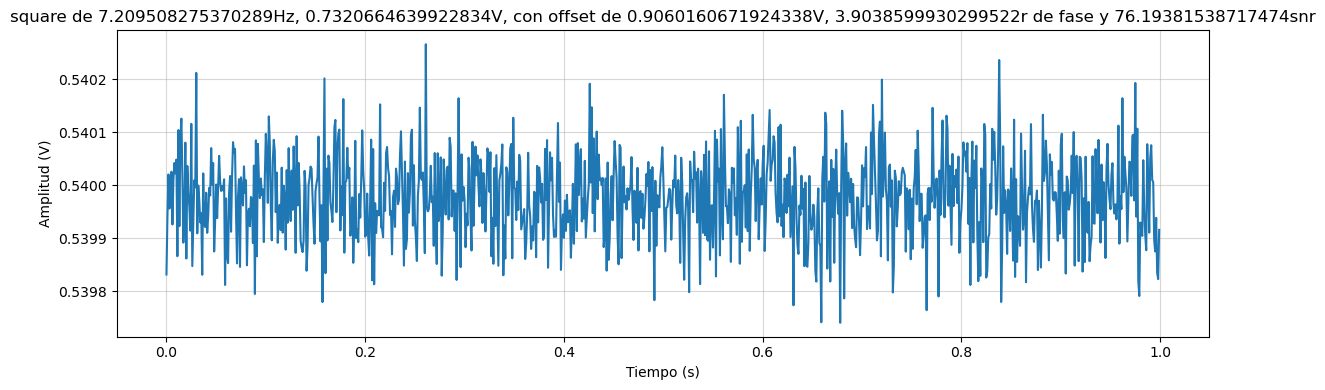

In [16]:
testSigGen (
sigType = "square",
vmax = np.random.uniform(0.5, 2),
dc = np.random.uniform(0.5, 2),
ff = np.random.uniform(6, 12),
ph = np.random.uniform(0, 2*np.pi),
fs = fs,
snr = np.random.uniform(10, 100)
)